<a href="https://colab.research.google.com/github/darshan123176/BWT_DevSpark/blob/main/day116.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import sklearn
import seaborn as sns

print("Python version :", sys.version.split()[0])
print("NumPy          :", np.__version__)
print("Pandas         :", pd.__version__)
print("Matplotlib     :", matplotlib.__version__)
print("scikit-learn   :", sklearn.__version__)
print("Seaborn        :", sns.__version__)


Python version : 3.12.13
NumPy          : 2.0.2
Pandas         : 2.2.2
Matplotlib     : 3.10.0
scikit-learn   : 1.6.1
Seaborn        : 0.13.2


In [1]:

import torch

print("PyTorch version :", torch.__version__)
print("GPU available   :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name        :", torch.cuda.get_device_name(0))
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print("GPU memory (GB) :", round(mem, 1))
else:
    print("No GPU. Runtime > Change runtime type > GPU")


PyTorch version : 2.11.0+cu128
GPU available   : True
GPU name        : Tesla T4
GPU memory (GB) : 15.6


In [2]:
!nvidia-smi


Mon Jun 29 09:29:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("Dataset shape :", df.shape)
df.head()


Dataset shape : (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df_csv = pd.read_csv(url)
print("Titanic shape:", df_csv.shape)
df_csv.head()


Titanic shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB


In [7]:
df.describe().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [8]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


In [9]:
df["species"].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


In [10]:
df.groupby("species", observed=True).mean().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


In [11]:
df.groupby("species", observed=True).mean().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")


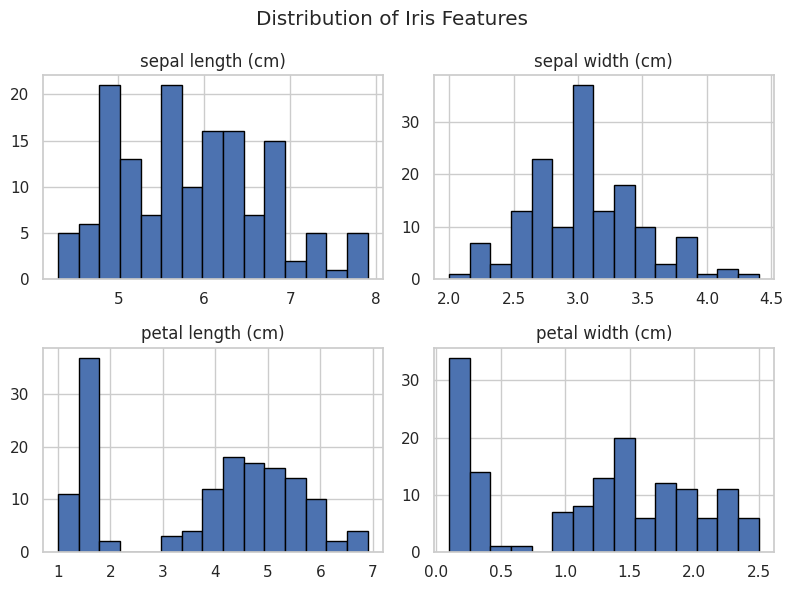

In [15]:
df.drop(columns="species").hist(figsize=(8, 6), bins=15, edgecolor="black")
plt.suptitle("Distribution of Iris Features")
plt.tight_layout()
plt.savefig("plot_histograms.png", dpi=100)
plt.show()


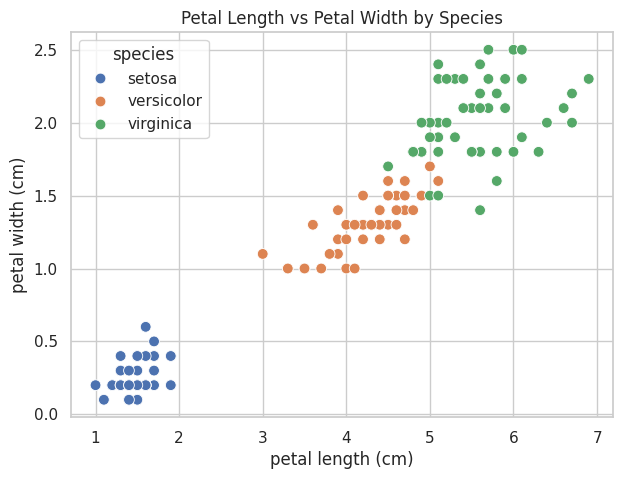

In [16]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="petal length (cm)", y="petal width (cm)",
                hue="species", s=60)
plt.title("Petal Length vs Petal Width by Species")
plt.savefig("plot_scatter.png", dpi=100)
plt.show()


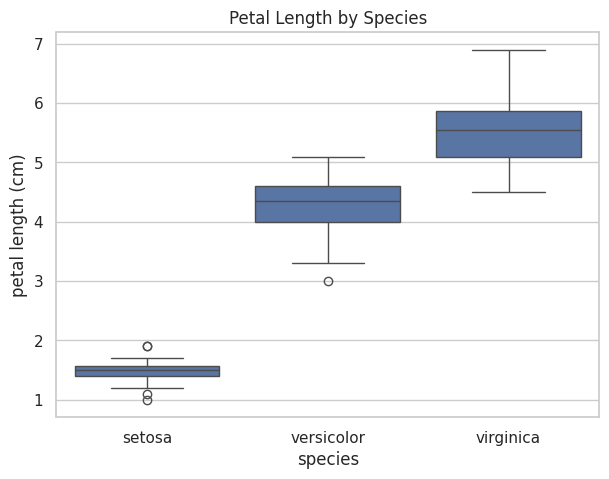

In [17]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="species", y="petal length (cm)")
plt.title("Petal Length by Species")
plt.savefig("plot_boxplot.png", dpi=100)
plt.show()


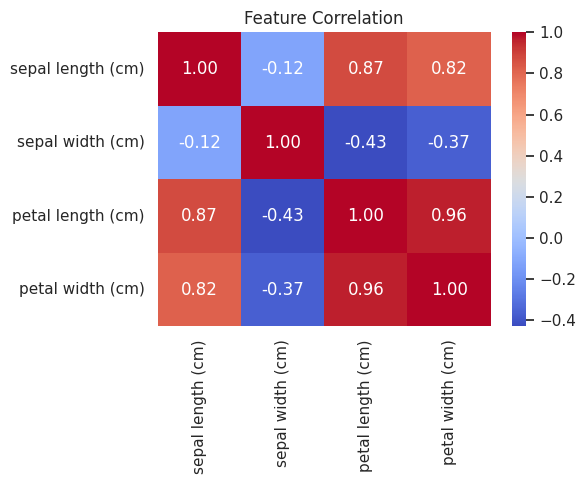

In [18]:
plt.figure(figsize=(6, 5))
corr = df.drop(columns="species").corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation")
plt.tight_layout()
plt.savefig("plot_heatmap.png", dpi=100)
plt.show()


In [19]:
import torch, time

size = 5000
a = torch.randn(size, size)
b = torch.randn(size, size)

# ---- CPU ----
start = time.time()
_ = torch.matmul(a, b)
cpu_time = time.time() - start
print(f"CPU time : {cpu_time:.4f} seconds")

# ---- GPU ----
if torch.cuda.is_available():
    a_gpu = a.cuda()
    b_gpu = b.cuda()

    # Warm-up (first GPU call loads CUDA kernels and is misleadingly slow)
    torch.cuda.synchronize()
    _ = torch.matmul(a_gpu, b_gpu)
    torch.cuda.synchronize()

    # Timed run
    start = time.time()
    _ = torch.matmul(a_gpu, b_gpu)
    torch.cuda.synchronize()   # wait for the GPU to finish
    gpu_time = time.time() - start

    print(f"GPU time : {gpu_time:.4f} seconds")
    print(f"GPU is ~{cpu_time / gpu_time:.1f}x faster than CPU")
else:
    print("No GPU available - enable it in Runtime settings.")


CPU time : 2.3423 seconds
GPU time : 0.0774 seconds
GPU is ~30.3x faster than CPU
